# West African Labour-Market Resilience — PhD-Ready XAI Pipeline

## Purpose

This notebook is a corrected, reproducible version of the original `emp_unemp909.ipynb`.

It preserves the original research direction—post-COVID employment recovery and unemployment vulnerability across 16 West African countries—but strengthens the methodology by:

- preventing panel leakage through **temporal and group-aware validation**;
- separating **descriptive recovery** from predictive modelling;
- comparing linear, random-forest, XGBoost and neural-network models on the **same test design**;
- using **permutation importance, SHAP, PDP and ICE** for explainability;
- testing whether the importance of `baseline_2020` and `recovery_score` survives alternative validation designs;
- correcting the vulnerability ranking direction;
- replacing the arbitrary 0.30 classification threshold with a **threshold-performance analysis**;
- avoiding causal claims that cannot be supported by the available variables.

> **Important:** The notebook requires the original `occupazione.csv` and `disoccupazione.csv` files in the working directory. The uploaded original notebook is used as the methodological basis, but those raw CSV files were not included with it.


## Research question

> **How can explainable machine learning identify structural persistence, demographic heterogeneity and nonlinear patterns in post-COVID labour-market outcomes in West Africa?**

### Main empirical distinction

The constructed measure

\[
Recovery_{i,t}=Employment_{i,t}-Employment_{i,2020}
\]

is treated as an **employment-recovery indicator**, not as a complete multidimensional resilience index.

The analysis therefore distinguishes:

1. **Descriptive recovery** — how employment changed relative to 2020.
2. **Predictive modelling** — how well unemployment can be predicted from observed labour-market and demographic variables.
3. **Explainability** — which variables and nonlinear patterns contribute to predictions.
4. **Vulnerability classification** — which observations receive high predicted probability of high unemployment.


In [1]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    TimeSeriesSplit,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COUNTRIES = [
    "Benin", "Burkina Faso", "Côte d'Ivoire", "Guinea", "Mali", "Niger",
    "Senegal", "Togo", "Gambia", "Ghana", "Liberia", "Nigeria",
    "Sierra Leone", "Cabo Verde", "Guinea-Bissau", "Mauritania"
]

DATA_DIR = Path(".")
print("Ready.")


Ready.


# 1. Load and merge the raw data

The original notebook loads employment and unemployment observations and merges them by:

- country code,
- country,
- sex,
- age,
- year.

The same structure is retained here.


In [2]:
# Load raw files
emp = pd.read_csv(DATA_DIR / "occupazione.csv")
unemp = pd.read_csv(DATA_DIR / "disoccupazione.csv")

emp = emp.rename(columns={"obs_value": "employment"})
unemp = unemp.rename(columns={"obs_value": "unemployment"})

merge_keys = ["iso_code", "country", "sex", "age", "year"]

df = emp.merge(
    unemp,
    on=merge_keys,
    how="inner",
    validate="one_to_one"
)

print("Shape:", df.shape)
print("Missing values:")
print(df[["employment", "unemployment"]].isna().sum())
df.head()


Shape: (57519, 7)
Missing values:
employment      0
unemployment    0
dtype: int64


,iso_code,country,sex,age,year,employment,unemployment
0,AFG,Afghanistan,Total,15+,2025,32.457,13.351
1,AFG,Afghanistan,Total,15-24,2025,31.419,16.785
2,AFG,Afghanistan,Total,25+,2025,33.056,11.340
3,AFG,Afghanistan,Male,15+,2025,61.038,12.503
4,AFG,Afghanistan,Male,15-24,2025,57.355,15.814


## Data integrity checks

Before modelling, verify that the panel keys are unique and that the expected dimensions are present.


In [3]:
# Standardize textual fields
for col in ["iso_code", "country", "sex", "age"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"\[|\]", "", regex=True)
        .str.strip()
    )

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["employment"] = pd.to_numeric(df["employment"], errors="coerce")
df["unemployment"] = pd.to_numeric(df["unemployment"], errors="coerce")

duplicate_keys = df.duplicated(merge_keys).sum()

print("Duplicate panel keys:", duplicate_keys)
print("Countries:", df["country"].nunique())
print("Sex categories:", sorted(df["sex"].dropna().unique()))
print("Age categories:", sorted(df["age"].dropna().unique()))
print("Years:", int(df["year"].min()), "to", int(df["year"].max()))

assert duplicate_keys == 0, "Panel keys are not unique."


Duplicate panel keys: 0
Countries: 183
Sex categories: ['Female', 'Male', 'Total']
Age categories: ['15+', '15-24', '25+']
Years: 1991 to 2025


# 2. Restrict to the analytical population

The original study uses 2020–2025 and 16 West African countries. We retain that analytical population.


In [4]:
W_A = df[
    df["country"].isin(COUNTRIES) &
    df["year"].between(2020, 2025)
].copy()

W_A = W_A.sort_values(["country", "sex", "age", "year"]).reset_index(drop=True)

print("West Africa panel shape:", W_A.shape)
print("Countries:", W_A["country"].nunique())
print("Years:", sorted(W_A["year"].unique()))
print("Rows by year:")
print(W_A.groupby("year").size())


West Africa panel shape: (864, 7)
Countries: 16
Years: [2020, 2021, 2022, 2023, 2024, 2025]
Rows by year:
year
2020    144
2021    144
2022    144
2023    144
2024    144
2025    144
dtype: int64


In [5]:
W_A.info()

<class 'pandas.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   iso_code      864 non-null    str    
 1   country       864 non-null    str    
 2   sex           864 non-null    str    
 3   age           864 non-null    str    
 4   year          864 non-null    int64  
 5   employment    864 non-null    float64
 6   unemployment  864 non-null    float64
dtypes: float64(2), int64(1), str(4)
memory usage: 64.3 KB


# 3. Construct the 2020 baseline and recovery score

For every country × sex × age subgroup:

\[
Baseline_{i}=Employment_{i,2020}
\]

and

\[
Recovery_{i,t}=Employment_{i,t}-Baseline_i.
\]

This is a transparent change-from-baseline measure. It should not be interpreted as a complete resilience index.


In [6]:
baseline = (
    W_A.loc[W_A["year"] == 2020, ["country", "sex", "age", "employment"]]
    .rename(columns={"employment": "baseline_2020"})
)

# One baseline per subgroup is required.
assert not baseline.duplicated(["country", "sex", "age"]).any()

W_A = W_A.merge(
    baseline,
    on=["country", "sex", "age"],
    how="left",
    validate="many_to_one"
)

W_A["recovery_score"] = W_A["employment"] - W_A["baseline_2020"]

print("Missing baselines:", W_A["baseline_2020"].isna().sum())
print("Rows:", len(W_A))
W_A.head()


Missing baselines: 0
Rows: 864


,iso_code,country,sex,age,year,employment,unemployment,baseline_2020,recovery_score
0,BEN,Benin,Female,15+,2020,72.507,1.469,72.507,0.000
1,BEN,Benin,Female,15+,2021,73.528,1.640,72.507,1.021
2,BEN,Benin,Female,15+,2022,73.527,1.483,72.507,1.020
3,BEN,Benin,Female,15+,2023,73.719,1.448,72.507,1.212
4,BEN,Benin,Female,15+,2024,73.901,1.446,72.507,1.394


# 4. Descriptive resilience analysis

The original notebook reports mean recovery by country and sex. These remain useful descriptive results, but they are labelled precisely.


In [7]:
country_recovery = (
    W_A.groupby("country", observed=True)["recovery_score"]
    .mean()
    .sort_values(ascending=False)
)

print("--- Mean employment recovery relative to 2020 ---")
display(country_recovery.to_frame("mean_recovery"))


--- Mean employment recovery relative to 2020 ---


,mean_recovery
country,
Niger,4.356278
Nigeria,3.563352
Cabo Verde,3.005722
Mali,1.554833
Benin,1.250759
Côte d'Ivoire,1.163111
Liberia,1.021593
Senegal,1.021481
Guinea-Bissau,0.483074


In [8]:
gender_recovery = (
    W_A.groupby("sex", observed=True)["recovery_score"]
    .mean()
    .sort_values(ascending=False)
)

print("--- Mean recovery by sex ---")
display(gender_recovery.to_frame("mean_recovery"))


--- Mean recovery by sex ---


,mean_recovery
sex,
Female,1.153510
Total,0.874128
Male,0.579622


In [9]:
# Recovery by country × sex × age
recovery_matrix = (
    W_A.groupby(["country", "sex", "age"], observed=True)["recovery_score"]
    .mean()
    .reset_index()
    .sort_values("recovery_score", ascending=False)
)

display(recovery_matrix.head(20))


,country,sex,age,recovery_score
100,Niger,Female,15-24,8.046667
99,Niger,Female,15+,6.690000
65,Guinea-Bissau,Female,25+,6.108833
109,Nigeria,Female,15-24,6.050333
101,Niger,Female,25+,5.913000
106,Niger,Total,15-24,5.799167
71,Guinea-Bissau,Total,25+,5.464667
68,Guinea-Bissau,Male,25+,4.716667
29,Côte d'Ivoire,Female,25+,4.488333
115,Nigeria,Total,15-24,4.355667


# 5. Exploratory relationship with unemployment

Pearson correlation is retained as a descriptive statistic, but a near-zero correlation is **not** by itself evidence of nonlinearity. Nonlinearity must be demonstrated through model diagnostics and explainability.


In [10]:
corr_all = W_A[["recovery_score", "unemployment"]].corr().iloc[0, 1]
corr_youth = (
    W_A.loc[W_A["age"] == "15-24", ["recovery_score", "unemployment"]]
    .corr().iloc[0, 1]
)
corr_adult = (
    W_A.loc[W_A["age"] == "25+", ["recovery_score", "unemployment"]]
    .corr().iloc[0, 1]
)

print(f"Overall Pearson r: {corr_all:.4f}")
print(f"Youth (15–24) Pearson r: {corr_youth:.4f}")
print(f"Adult (25+) Pearson r: {corr_adult:.4f}")


Overall Pearson r: -0.0244
Youth (15–24) Pearson r: 0.0505
Adult (25+) Pearson r: -0.0519


# 6. Define modelling data

The target is unemployment.

We explicitly acknowledge that employment and unemployment are related labour-market indicators. Therefore, the model is interpreted as a **predictive relationship model**, not a causal model.


In [11]:
features_full = [
    "year",
    "employment",
    "baseline_2020",
    "recovery_score",
    "sex",
    "age"
]

target = "unemployment"

model_df = W_A[features_full + [target]].dropna().copy()

# A grouping identifier for country × sex × age.
model_df["panel_group"] = (
    model_df["sex"].astype(str) + "__" +
    model_df["age"].astype(str) + "__" +
    model_df.index.map(lambda x: str(x))  # placeholder replaced below
)

# Use the original country identity from W_A.
model_df["country"] = W_A.loc[model_df.index, "country"].values

# Stable longitudinal subgroup identifier
model_df["panel_group"] = (
    model_df["country"].astype(str) + "__" +
    model_df["sex"].astype(str) + "__" +
    model_df["age"].astype(str)
)

print(model_df.shape)


(864, 9)


# 7. Validation design — the key methodological correction

A random row-wise split is not sufficient for a longitudinal country/sex/age panel because related observations from the same subgroup can appear in both train and test sets.

We therefore report three complementary designs:

1. **Random split** — retained only as a benchmark against the original notebook.
2. **Temporal split** — train on 2020–2023, test on 2024–2025.
3. **Country-group validation** — entire countries are held out from training.

The temporal and country-held-out results are the primary evidence for generalization.


In [12]:
# Random benchmark split
X = model_df[features_full].copy()
y = model_df[target].copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Temporal split
train_mask = model_df["year"] <= 2023
test_mask = model_df["year"] >= 2024

X_train_t = model_df.loc[train_mask, features_full].copy()
X_test_t = model_df.loc[test_mask, features_full].copy()
y_train_t = model_df.loc[train_mask, target].copy()
y_test_t = model_df.loc[test_mask, target].copy()

print("Random benchmark:", len(X_train_r), "train /", len(X_test_r), "test")
print("Temporal:", len(X_train_t), "train /", len(X_test_t), "test")


Random benchmark: 691 train / 173 test
Temporal: 576 train / 288 test


# 8. Preprocessing

Categorical variables are one-hot encoded. Numeric variables are passed through with median imputation.

This prevents manually imposed ordinal codes such as `Female=2`, `Male=1`, `Total=0` from creating artificial numerical distances.


In [13]:
numeric_features = ["year", "employment", "baseline_2020", "recovery_score"]
categorical_features = ["sex", "age"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)


# 9. Model definitions

The same preprocessing and evaluation protocol is used for each algorithm.

Models:

- Linear Regression — interpretable baseline.
- Random Forest — nonlinear tree ensemble.
- XGBoost — primary nonlinear model.
- MLP Regressor — neural-network comparison.

The neural network is evaluated on the same untouched test sets as the other models.


In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=RANDOM_STATE
    )
}

def make_pipeline(model):
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred)
    }


# 10. Random-split benchmark

This is included so the new notebook can be directly compared with the original reported XGBoost result. It is **not** treated as the strongest generalization test.


In [15]:
benchmark_results = []
benchmark_predictions = {}

for name, model in models.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train_r, y_train_r)
    pred = pipe.predict(X_test_r)
    benchmark_predictions[name] = (y_test_r.copy(), pred)
    benchmark_results.append({
        "Validation": "Random 80/20",
        "Model": name,
        **regression_metrics(y_test_r, pred)
    })

benchmark_results_df = pd.DataFrame(benchmark_results).sort_values("R2", ascending=False)
display(benchmark_results_df)


,Validation,Model,MAE,RMSE,R2
2,Random 80/20,XGBoost,1.038864,1.574615,0.892308
1,Random 80/20,Random Forest,1.016091,1.577373,0.891930
3,Random 80/20,Neural Network,2.237658,3.134483,0.573256
0,Random 80/20,Linear Regression,2.871283,3.929509,0.329325


# 11. Temporal out-of-sample evaluation

This is the primary forecasting-style test:

- Training: 2020–2023
- Test: 2024–2025

No 2024–2025 observations are used for fitting.


In [16]:
temporal_results = []
temporal_predictions = {}

for name, model in models.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train_t, y_train_t)
    pred = pipe.predict(X_test_t)
    temporal_predictions[name] = (y_test_t.copy(), pred)
    temporal_results.append({
        "Validation": "Temporal 2020–2023 → 2024–2025",
        "Model": name,
        **regression_metrics(y_test_t, pred)
    })

temporal_results_df = pd.DataFrame(temporal_results).sort_values("R2", ascending=False)
display(temporal_results_df)


,Validation,Model,MAE,RMSE,R2
2,Temporal 2020–2023 → 2024–2025,XGBoost,0.574328,0.788653,0.978486
1,Temporal 2020–2023 → 2024–2025,Random Forest,0.623135,0.990592,0.966059
0,Temporal 2020–2023 → 2024–2025,Linear Regression,2.696951,4.127211,0.410813
3,Temporal 2020–2023 → 2024–2025,Neural Network,3.184409,4.633192,0.257494


# 12. Country holdout evaluation

The strongest generalization test asks whether the model can operate on countries that were not used during training.

A Leave-One-Country-Out design is appropriate for only 16 countries, although it is computationally more expensive.


In [17]:
# Country-level out-of-sample evaluation
country_results = []

for held_out_country in sorted(model_df["country"].unique()):
    train = model_df["country"] != held_out_country
    test = model_df["country"] == held_out_country

    Xtr = model_df.loc[train, features_full]
    ytr = model_df.loc[train, target]
    Xte = model_df.loc[test, features_full]
    yte = model_df.loc[test, target]

    # XGBoost is the primary model for this generalization test.
    pipe = make_pipeline(models["XGBoost"])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)

    country_results.append({
        "Held_out_country": held_out_country,
        "N_test": len(yte),
        **regression_metrics(yte, pred)
    })

country_results_df = pd.DataFrame(country_results).sort_values("R2", ascending=False)
display(country_results_df)
print("\nMean country-holdout R2:", country_results_df["R2"].mean())


,Held_out_country,N_test,MAE,RMSE,R2
10,Mauritania,54,5.279254,6.308391,0.380377
3,Côte d'Ivoire,54,0.882918,1.064829,0.102834
2,Cabo Verde,54,9.637612,11.010899,-0.323765
12,Nigeria,54,2.504634,3.009965,-0.556054
9,Mali,54,1.100378,1.429854,-0.559293
5,Ghana,54,1.344508,1.874193,-0.665183
1,Burkina Faso,54,2.070968,2.902464,-0.993158
4,Gambia,54,2.723686,3.496869,-1.034692
6,Guinea,54,1.573888,1.849067,-1.146190
0,Benin,54,1.477026,1.826059,-3.949774



Mean country-holdout R2: -30.15782885227699


# 13. Feature ablation

To test whether `baseline_2020` really contributes substantial predictive information, we compare nested feature sets.

### A — Demographic
`year + sex + age`

### B — Structural
A + `baseline_2020`

### C — Recovery
B + `recovery_score`

### D — Full
C + `employment`

This is more informative than relying on one feature-importance score.


In [18]:
feature_sets = {
    "A_Demographic": ["year", "sex", "age"],
    "B_Structural": ["year", "sex", "age", "baseline_2020"],
    "C_Recovery": ["year", "sex", "age", "baseline_2020", "recovery_score"],
    "D_Full": features_full
}

ablation_results = []

for label, feats in feature_sets.items():
    pipe_preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]),
             [f for f in feats if f in numeric_features]),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), [f for f in feats if f in categorical_features])
        ]
    )

    pipe = Pipeline([
        ("preprocess", pipe_preprocessor),
        ("model", xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    pipe.fit(X_train_t[feats], y_train_t)
    pred = pipe.predict(X_test_t[feats])

    ablation_results.append({
        "Feature_set": label,
        "Features": ", ".join(feats),
        **regression_metrics(y_test_t, pred)
    })

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)


,Feature_set,Features,MAE,RMSE,R2
0,A_Demographic,"year, sex, age",3.155973,5.087979,0.104573
1,B_Structural,"year, sex, age, baseline_2020",0.582277,0.792715,0.978264
2,C_Recovery,"year, sex, age, baseline_2020, recovery_score",0.594744,0.839647,0.975614
3,D_Full,"year, employment, baseline_2020, recovery_scor...",0.574328,0.788653,0.978486


# 14. XGBoost explainability

The original notebook uses Gain importance and permutation importance. These are retained, but SHAP is added as the principal local/global explanation method.

Interpretation rule:

> Importance indicates predictive contribution, not causality.


In [19]:
# Fit final XGBoost model on the temporal training set
final_xgb = make_pipeline(models["XGBoost"])
final_xgb.fit(X_train_t, y_train_t)

# Extract transformed matrices and fitted estimator
X_train_trans = final_xgb.named_steps["preprocess"].transform(X_train_t)
X_test_trans = final_xgb.named_steps["preprocess"].transform(X_test_t)
xgb_estimator = final_xgb.named_steps["model"]

feature_names = final_xgb.named_steps["preprocess"].get_feature_names_out()

# Gain importance
gain = pd.Series(
    xgb_estimator.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

display(gain.head(20).to_frame("importance"))


,importance
num__baseline_2020,0.293054
cat__sex_Total,0.149701
cat__sex_Female,0.135732
num__employment,0.102360
cat__age_15-24,0.082563
num__recovery_score,0.063386
cat__age_15+,0.056846
cat__sex_Male,0.053275
cat__age_25+,0.038404
num__year,0.024681


In [20]:
# Permutation importance on the untouched temporal test set
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    final_xgb,
    X_test_t,
    y_test_t,
    scoring="r2",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test_t.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df)


,feature,importance_mean,importance_std
2,baseline_2020,1.362746,0.102148
1,employment,0.126427,0.010046
4,sex,0.084420,0.020438
3,recovery_score,0.081104,0.016624
5,age,0.073644,0.008009
0,year,0.000000,0.000000


In [21]:
# 14a. Package compatibility diagnostics
# This cell is informational and does not alter the fitted model.
try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    print("SHAP is not installed; the notebook will continue without SHAP plots.")

print("XGBoost version:", xgb.__version__)


SHAP version: 0.48.0
XGBoost version: 3.2.0


## SHAP

SHAP is used for global explanation of the temporal test-set predictions.

The implementation below uses **XGBoost's native Tree SHAP (`pred_contribs=True`)** rather than relying on SHAP's model parser. This is intentional: XGBoost 3.x may represent its base score as a vector string such as `[5.328047E0]`, which can cause older SHAP/XGBoost combinations to fail during `TreeExplainer` construction.

The native contribution matrix is equivalent to the Tree SHAP contribution output for the fitted XGBoost model; the final contribution column is the expected/base value and is excluded from feature-level importance.

If the `shap` package is unavailable or another compatibility problem occurs, the notebook continues with permutation importance and PDP/ICE rather than failing.


SHAP values computed successfully: (288, 10)
Mean absolute SHAP contribution: 0.517748


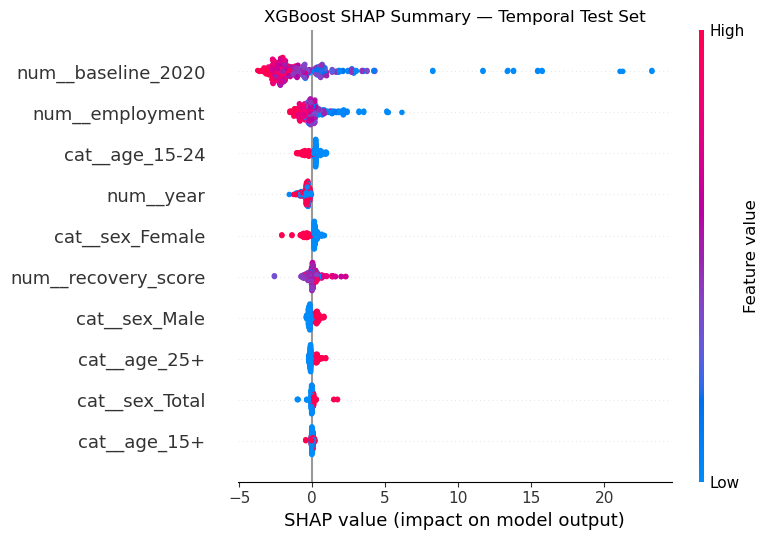

,feature,mean_abs_shap
0,num__baseline_2020,2.545911
1,num__employment,0.668937
2,cat__age_15-24,0.383104
3,num__year,0.368016
4,cat__sex_Female,0.319324
5,num__recovery_score,0.301541
6,cat__sex_Male,0.252909
7,cat__age_25+,0.196333
8,cat__sex_Total,0.102137
9,cat__age_15+,0.039269


In [22]:
# SHAP explainability — version-robust implementation
#
# XGBoost 3.x can store a vector-valued base_score such as "[5.328047E0]".
# Older SHAP releases may try to parse that value as a scalar float and raise:
#     ValueError: could not convert string to float: '[5.328047E0]'
#
# To avoid that compatibility problem, SHAP contributions are obtained directly
# from XGBoost's native pred_contribs interface. These are Tree SHAP contributions
# and can be passed to SHAP's plotting functions without TreeExplainer parsing
# the XGBoost model configuration.

try:
    import shap
    import numpy as np
    import xgboost as xgb

    # Convert the transformed test matrix to a clean numeric float64 array.
    X_test_dense = X_test_trans.toarray() if hasattr(X_test_trans, "toarray") else np.asarray(X_test_trans)
    X_test_dense = np.asarray(X_test_dense, dtype=np.float64)
    feature_names = np.asarray(feature_names, dtype=str)

    # Native XGBoost Tree SHAP. The final column is the expected/base value.
    booster = xgb_estimator.get_booster()
    dtest_shap = xgb.DMatrix(X_test_dense)
    shap_with_base = booster.predict(dtest_shap, pred_contribs=True)
    shap_values = np.asarray(shap_with_base[:, :-1], dtype=np.float64)
    shap_base_values = np.asarray(shap_with_base[:, -1], dtype=np.float64)

    if shap_values.shape[1] != len(feature_names):
        raise ValueError(
            f"SHAP feature mismatch: {shap_values.shape[1]} values for "
            f"{len(feature_names)} transformed features."
        )

    print(f"SHAP values computed successfully: {shap_values.shape}")
    print(f"Mean absolute SHAP contribution: {np.abs(shap_values).mean():.6f}")

    # Global SHAP summary.
    shap.summary_plot(
        shap_values,
        X_test_dense,
        feature_names=feature_names.tolist(),
        show=False
    )
    plt.title("XGBoost SHAP Summary — Temporal Test Set")
    plt.tight_layout()
    plt.show()

    # Global mean absolute SHAP importance for thesis tables.
    shap_importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0)
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    display(shap_importance_df.head(20))

except ImportError:
    print("SHAP is not installed. Install it with: pip install -U shap")
except Exception as e:
    print("SHAP analysis could not be completed:", repr(e))
    print("Permutation importance and PDP/ICE remain available and are unaffected.")


# 15. Partial dependence and ICE

PDP estimates the average model response as a feature changes.

ICE displays individual conditional response curves.

These are used to investigate whether the recovery–unemployment relationship is actually nonlinear or heterogeneous rather than inferring nonlinearity from Pearson correlation alone.


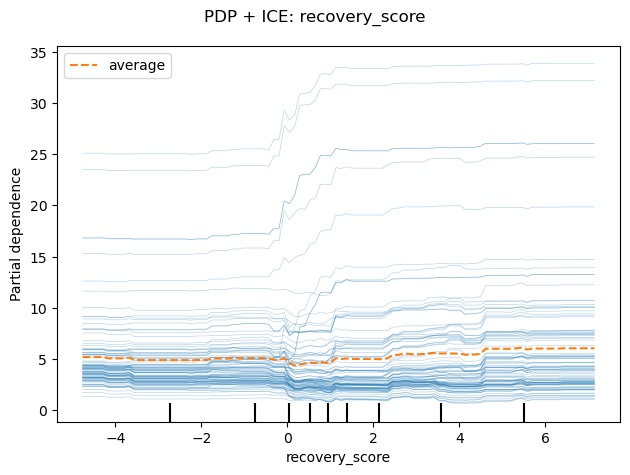

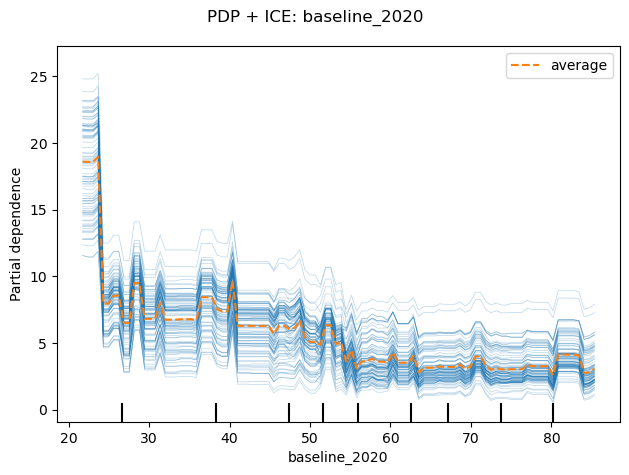

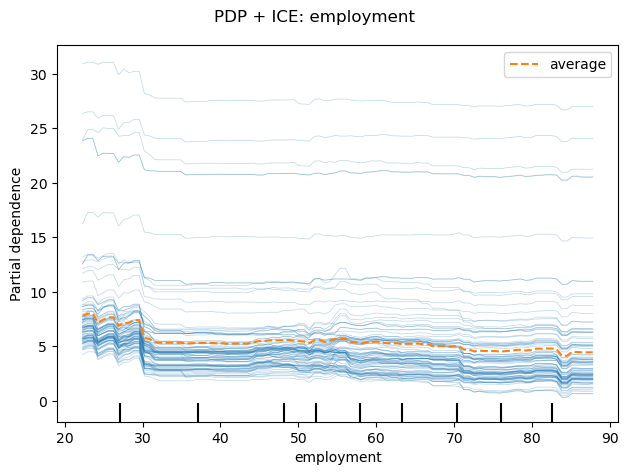

In [23]:
from sklearn.inspection import PartialDependenceDisplay

for feature in ["recovery_score", "baseline_2020", "employment"]:
    PartialDependenceDisplay.from_estimator(
        final_xgb,
        X_test_t,
        [feature],
        kind="both",
        subsample=min(100, len(X_test_t)),
        random_state=RANDOM_STATE
    )
    plt.suptitle(f"PDP + ICE: {feature}")
    plt.tight_layout()
    plt.show()


# 16. Vulnerability classification

We define a binary vulnerability outcome transparently:

\[
V_i =
\begin{cases}
1 & \text{if unemployment is above the training-set median}\\
0 & \text{otherwise}
\end{cases}
\]

The threshold is calculated **from the training data only**, avoiding test-set information leakage.

This classification should be interpreted as a relative high-unemployment classification, not a clinical/social-risk diagnosis.


In [24]:
# Binary target based only on training-set information
vulnerability_cutoff = y_train_t.median()

y_train_bin = (y_train_t > vulnerability_cutoff).astype(int)
y_test_bin = (y_test_t > vulnerability_cutoff).astype(int)

classifier = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

classifier.fit(X_train_t, y_train_bin)

y_prob = classifier.predict_proba(X_test_t)[:, 1]

print("Training median cutoff:", vulnerability_cutoff)
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob))
print("PR-AUC:", average_precision_score(y_test_bin, y_prob))


Training median cutoff: 3.522
ROC-AUC: 0.985837922895358
PR-AUC: 0.9772601894001474


# 17. Threshold analysis

Instead of selecting 0.30 arbitrarily, evaluate multiple thresholds.

The operational threshold can then be selected according to the research objective—for example, prioritising recall when false negatives are more costly.


In [25]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    pred_bin = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, pred_bin, labels=[0, 1]).ravel()

    precision = precision_score(y_test_bin, pred_bin, zero_division=0)
    recall = recall_score(y_test_bin, pred_bin, zero_division=0)
    f1 = f1_score(y_test_bin, pred_bin, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)


,threshold,precision,recall,specificity,f1,TP,FP,TN,FN
0,0.10,0.652632,1.000000,0.597561,0.789809,124,66,98,0
1,0.15,0.720930,1.000000,0.707317,0.837838,124,48,116,0
2,0.20,0.784810,1.000000,0.792683,0.879433,124,34,130,0
3,0.25,0.832215,1.000000,0.847561,0.908425,124,25,139,0
4,0.30,0.879433,1.000000,0.896341,0.935849,124,17,147,0
5,0.35,0.905109,1.000000,0.920732,0.950192,124,13,151,0
6,0.40,0.911111,0.991935,0.926829,0.949807,123,12,152,1
7,0.45,0.931818,0.991935,0.945122,0.960938,123,9,155,1
8,0.50,0.930233,0.967742,0.945122,0.948617,120,9,155,4
9,0.55,0.941667,0.911290,0.957317,0.926230,113,7,157,11


# 18. Correct vulnerability ranking

Class-1 probability is interpreted as predicted high-unemployment vulnerability.

Therefore, the ranking must be **descending**, not ascending.


In [26]:
ranking_df = W_A.loc[
    X_test_t.index,
    ["country", "sex", "age", "year", "employment", "unemployment", "baseline_2020", "recovery_score"]
].copy()

ranking_df["vulnerability_probability"] = y_prob

top_10_risk = ranking_df.sort_values(
    "vulnerability_probability",
    ascending=False
).head(10)

print("--- Top 10 predicted high-vulnerability observations ---")
display(top_10_risk)


--- Top 10 predicted high-vulnerability observations ---


,country,sex,age,year,employment,unemployment,baseline_2020,recovery_score,vulnerability_probability
118,Cabo Verde,Female,15-24,2024,17.009,33.582,13.528,3.481,0.986919
119,Cabo Verde,Female,15-24,2025,16.841,33.901,13.528,3.313,0.986035
154,Cabo Verde,Total,15-24,2024,22.215,28.100,18.878,3.337,0.979820
557,Mauritania,Female,25+,2025,28.973,11.778,28.451,0.522,0.975898
556,Mauritania,Female,25+,2024,28.987,11.892,28.451,0.536,0.975898
281,Ghana,Female,15-24,2025,27.126,5.736,29.878,-2.752,0.975748
785,Sierra Leone,Male,15-24,2025,27.327,5.054,28.019,-0.692,0.975564
784,Sierra Leone,Male,15-24,2024,27.445,4.649,28.019,-0.574,0.974778
262,Gambia,Total,15-24,2024,27.427,10.830,28.138,-0.711,0.973321
263,Gambia,Total,15-24,2025,27.392,10.863,28.138,-0.746,0.973321


# 19. Vulnerability aggregation

Country and demographic vulnerability are summarised from the model probabilities.

These are **model-derived probabilities**, not observed probabilities of social harm.


In [27]:
country_vulnerability = (
    ranking_df.groupby("country")["vulnerability_probability"]
    .mean()
    .sort_values(ascending=False)
)

sex_age_vulnerability = (
    ranking_df.groupby(["sex", "age"])["vulnerability_probability"]
    .mean()
    .sort_values(ascending=False)
)

print("--- Country vulnerability ---")
display(country_vulnerability.to_frame())

print("--- Sex × age vulnerability ---")
display(sex_age_vulnerability.to_frame())


--- Country vulnerability ---


,vulnerability_probability
country,
Cabo Verde,0.948283
Gambia,0.924460
Mauritania,0.903475
Guinea,0.694183
Burkina Faso,0.503740
Sierra Leone,0.495106
Ghana,0.451600
Nigeria,0.390901
Senegal,0.345704


--- Sex × age vulnerability ---


,,vulnerability_probability
sex,age,
Male,15-24,0.741822
Total,15-24,0.682115
Female,15-24,0.662769
Male,15+,0.387586
Female,15+,0.374996
Total,15+,0.325776
Male,25+,0.320577
Female,25+,0.270973
Total,25+,0.261943


--- Country vulnerability ---


country
Cabo Verde       0.948283
Gambia           0.924460
Mauritania       0.903475
Guinea           0.694183
Burkina Faso     0.503740
Sierra Leone     0.495106
Ghana            0.451600
Nigeria          0.390901
Senegal          0.345704
Côte d'Ivoire    0.325119
Togo             0.305434
Mali             0.298567
Guinea-Bissau    0.204997
Liberia          0.160863
Benin            0.154348
Niger            0.055100
Name: vulnerability_probability, dtype: float32

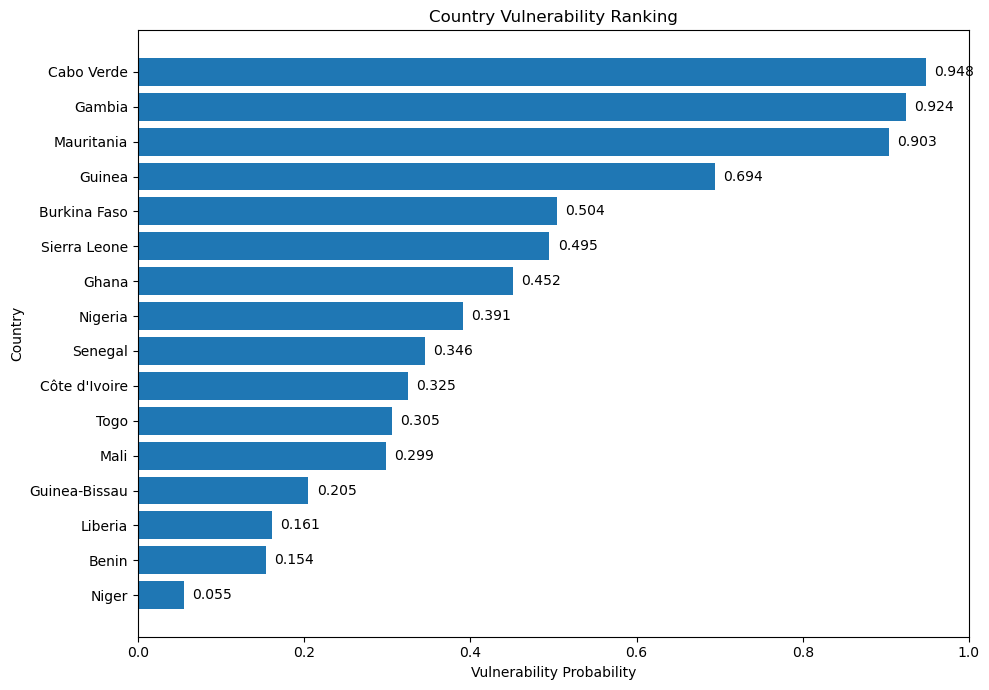

In [28]:
# Country-level vulnerability aggregation
country_vulnerability = (
    ranking_df.groupby("country")["vulnerability_probability"]
    .mean()
    .sort_values(ascending=False)
)

print("--- Country vulnerability ---")
display(country_vulnerability)

# Plot country vulnerability
plt.figure(figsize=(10, 7))

plt.barh(
    country_vulnerability.index,
    country_vulnerability.values
)

plt.gca().invert_yaxis()

plt.xlabel("Vulnerability Probability")
plt.ylabel("Country")
plt.title("Country Vulnerability Ranking")

plt.xlim(0, 1)

# Add probability values
for i, value in enumerate(country_vulnerability.values):
    plt.text(
        value + 0.01,
        i,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# 20. Recovery versus vulnerability

A key substantive question is whether strong employment recovery automatically implies low unemployment vulnerability.

It should not be assumed.

We therefore compare the descriptive recovery score with model-derived vulnerability.


In [29]:
country_summary = (
    W_A.groupby("country", observed=True)["recovery_score"]
    .mean()
    .rename("mean_recovery")
    .to_frame()
    .join(country_vulnerability.rename("mean_vulnerability"), how="left")
)

display(country_summary.sort_values("mean_vulnerability", ascending=False))

print(
    "Country-level correlation between recovery and vulnerability:",
    country_summary["mean_recovery"].corr(country_summary["mean_vulnerability"])
)


,mean_recovery,mean_vulnerability
country,,
Cabo Verde,3.005722,0.948283
Gambia,-0.387815,0.924460
Mauritania,0.421889,0.903475
Guinea,0.345630,0.694183
Burkina Faso,-2.715148,0.503740
Sierra Leone,0.216778,0.495106
Ghana,-1.796389,0.451600
Nigeria,3.563352,0.390901
Senegal,1.021481,0.345704


Country-level correlation between recovery and vulnerability: -0.23473404081378527


Country-level correlation: -0.219


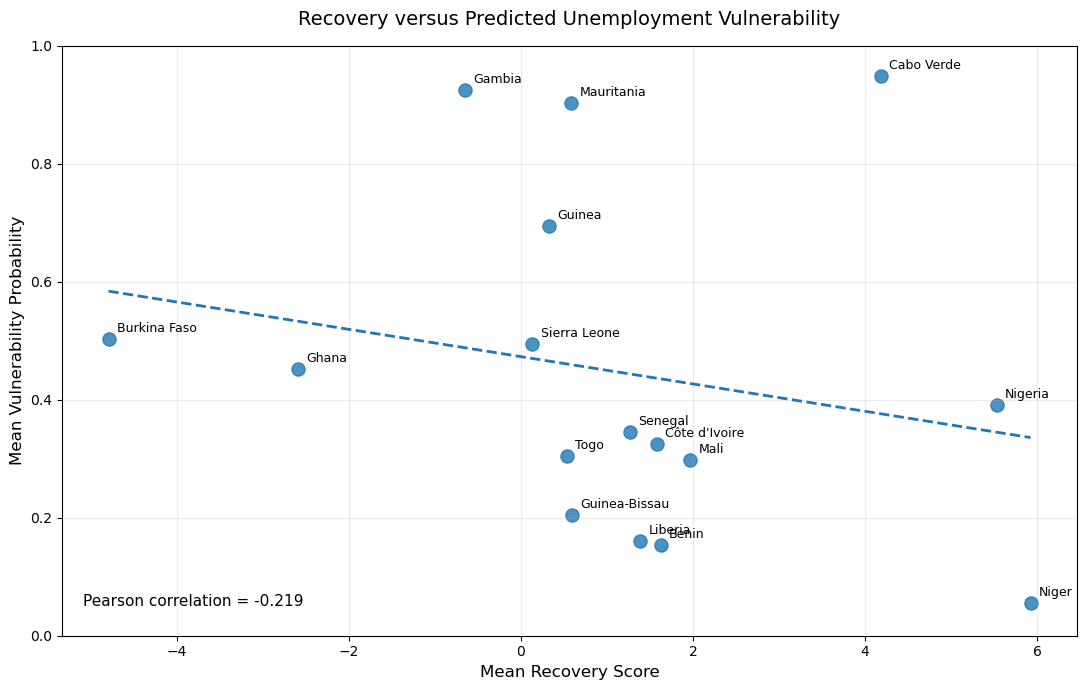

In [30]:
# ============================================================
# 20. RECOVERY VERSUS VULNERABILITY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Create a clean DataFrame
recovery_vulnerability = (
    ranking_df.groupby("country")
    .agg(
        mean_recovery=("recovery_score", "mean"),
        mean_vulnerability=("vulnerability_probability", "mean")
    )
    .reset_index()
)

# Calculate correlation
correlation = recovery_vulnerability[
    "mean_recovery"
].corr(
    recovery_vulnerability["mean_vulnerability"]
)

print(f"Country-level correlation: {correlation:.3f}")

# ------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    recovery_vulnerability["mean_recovery"],
    recovery_vulnerability["mean_vulnerability"],
    s=90,
    alpha=0.8
)

# Add country labels
for _, row in recovery_vulnerability.iterrows():
    plt.annotate(
        row["country"],
        (row["mean_recovery"], row["mean_vulnerability"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9
    )

# Add regression/trend line
x = recovery_vulnerability["mean_recovery"].values
y = recovery_vulnerability["mean_vulnerability"].values

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=2
)

# Labels and title
plt.xlabel("Mean Recovery Score", fontsize=12)
plt.ylabel("Mean Vulnerability Probability", fontsize=12)

plt.title(
    "Recovery versus Predicted Unemployment Vulnerability",
    fontsize=14,
    pad=15
)

# Vulnerability probability is bounded between 0 and 1
plt.ylim(0, 1)

# Show correlation on the graph
plt.text(
    0.02,
    0.05,
    f"Pearson correlation = {correlation:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 21. Robustness: alternative baseline

The 2020 baseline is substantively meaningful because it represents the beginning of the post-COVID observation window, but 2020 is itself a shock year.

If 2019 observations exist, construct an alternative pre-COVID baseline and compare country rankings.

This is a robustness test—not a replacement of the primary specification.


In [31]:
if 2019 in set(df["year"].dropna().astype(int)):
    baseline_2019 = (
        df[df["country"].isin(COUNTRIES) & (df["year"] == 2019)]
        [["country", "sex", "age", "employment"]]
        .rename(columns={"employment": "baseline_2019"})
    )

    W_alt = W_A.merge(
        baseline_2019,
        on=["country", "sex", "age"],
        how="left",
        validate="many_to_one"
    )

    W_alt["recovery_from_2019"] = (
        W_alt["employment"] - W_alt["baseline_2019"]
    )

    alt_country = (
        W_alt.groupby("country")["recovery_from_2019"]
        .mean()
        .sort_values(ascending=False)
    )

    print("--- Alternative 2019-baseline recovery ranking ---")
    display(alt_country.to_frame())
else:
    print("2019 data are not available in the loaded source files.")


--- Alternative 2019-baseline recovery ranking ---


,recovery_from_2019
country,
Niger,6.237278
Nigeria,1.566241
Benin,0.874759
Senegal,0.778259
Côte d'Ivoire,0.702556
Togo,-0.216315
Guinea-Bissau,-0.270148
Mauritania,-0.285444
Mali,-0.313611


# 22. Final evidence table

The final results table should distinguish:

- descriptive recovery;
- predictive performance;
- feature importance;
- vulnerability;
- robustness.

Do not report a single XGBoost R² as if it establishes causal validity.


In [32]:
final_evidence = {
    "Random benchmark": benchmark_results_df,
    "Temporal validation": temporal_results_df,
    "Feature ablation": ablation_df,
    "Country holdout": country_results_df
}

for name, table in final_evidence.items():
    print("\n###", name)
    display(table)



### Random benchmark


,Validation,Model,MAE,RMSE,R2
2,Random 80/20,XGBoost,1.038864,1.574615,0.892308
1,Random 80/20,Random Forest,1.016091,1.577373,0.891930
3,Random 80/20,Neural Network,2.237658,3.134483,0.573256
0,Random 80/20,Linear Regression,2.871283,3.929509,0.329325



### Temporal validation


,Validation,Model,MAE,RMSE,R2
2,Temporal 2020–2023 → 2024–2025,XGBoost,0.574328,0.788653,0.978486
1,Temporal 2020–2023 → 2024–2025,Random Forest,0.623135,0.990592,0.966059
0,Temporal 2020–2023 → 2024–2025,Linear Regression,2.696951,4.127211,0.410813
3,Temporal 2020–2023 → 2024–2025,Neural Network,3.184409,4.633192,0.257494



### Feature ablation


,Feature_set,Features,MAE,RMSE,R2
0,A_Demographic,"year, sex, age",3.155973,5.087979,0.104573
1,B_Structural,"year, sex, age, baseline_2020",0.582277,0.792715,0.978264
2,C_Recovery,"year, sex, age, baseline_2020, recovery_score",0.594744,0.839647,0.975614
3,D_Full,"year, employment, baseline_2020, recovery_scor...",0.574328,0.788653,0.978486



### Country holdout


,Held_out_country,N_test,MAE,RMSE,R2
10,Mauritania,54,5.279254,6.308391,0.380377
3,Côte d'Ivoire,54,0.882918,1.064829,0.102834
2,Cabo Verde,54,9.637612,11.010899,-0.323765
12,Nigeria,54,2.504634,3.009965,-0.556054
9,Mali,54,1.100378,1.429854,-0.559293
5,Ghana,54,1.344508,1.874193,-0.665183
1,Burkina Faso,54,2.070968,2.902464,-0.993158
4,Gambia,54,2.723686,3.496869,-1.034692
6,Guinea,54,1.573888,1.849067,-1.146190
0,Benin,54,1.477026,1.826059,-3.949774


# 23. Thesis-safe interpretation template

Use the following logic when writing the results chapter:

### Supported

- Employment recovery differs substantially across countries and demographic groups.
- The original descriptive ranking identifies substantial heterogeneity in change from the 2020 employment baseline.
- Nonlinear models can be compared with linear models under identical validation designs.
- Feature importance can identify variables with predictive value.
- PDP/ICE/SHAP can reveal nonlinear and heterogeneous model behaviour.
- The vulnerability classifier can identify observations with high predicted probability of the defined high-unemployment class.

### Do not claim without additional evidence

- Causality.
- That XGBoost “proves” jobless growth.
- That sectoral composition caused the observed threshold.
- That a high feature importance score proves path dependence.
- That random-split R² represents real-world forecasting performance.

### Preferred wording

> “The results indicate…”

> “The model identifies…”

> “The evidence is consistent with…”

> “The pattern motivates the hypothesis that…”

rather than:

> “This proves…”


# 24. Reproducibility and export

Save the cleaned panel and model outputs with explicit versioned filenames.

Never hard-code performance metrics into figures; calculate them from the fitted predictions.


In [33]:
# Export analytical datasets and results
W_A.to_csv("west_africa_cleaned_phd_ready.csv", index=False)

benchmark_results_df.to_csv("model_results_random_benchmark.csv", index=False)
temporal_results_df.to_csv("model_results_temporal.csv", index=False)
country_results_df.to_csv("model_results_country_holdout.csv", index=False)
ablation_df.to_csv("model_results_feature_ablation.csv", index=False)
threshold_df.to_csv("vulnerability_threshold_analysis.csv", index=False)
country_summary.to_csv("country_recovery_vulnerability_summary.csv")

print("Exports completed.")


PermissionError: [Errno 13] Permission denied: 'west_africa_cleaned_phd_ready.csv'

# Final conclusion

The corrected methodology treats the project as an **explainable predictive framework for labour-market resilience**, rather than as a causal econometric model.

The most important empirical questions are now:

1. Does XGBoost outperform linear models under **temporal** validation?
2. Does it generalize to **countries excluded from training**?
3. Does `baseline_2020` retain importance under feature ablation?
4. Does `recovery_score` add predictive information after controlling for the baseline?
5. Are apparent nonlinearities visible in PDP/ICE/SHAP?
6. Are demographic vulnerability patterns stable across validation designs?
7. Do the conclusions survive an alternative pre-COVID baseline where available?

If the answers remain positive after these tests, the thesis argument becomes substantially stronger than the original random-split analysis.
